# Image Deblurring - Synthetic Degradation
### MATH 441 Convex Optimization

**Objective Function:**
$$ \underset{\mathbf{u}}{\min} \underbrace{\|H\mathbf{u}-\mathbf{f}\|_2^2}_{\text{data fidelity}} + \lambda\underbrace{\sum_{i,j}\|\nabla u_{i,j}\|_2}_{\text{TV (isotropic)}} \quad\text{s.t.}\quad 0\leq\mathbf{u}\leq 1 $$

**Degradation:** Gaussian blur ($\sigma=1.5$)

## Installing and Importing Packages

In [1]:
%pip install -qq numpy matplotlib cvxpy scipy scikit-image

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import scipy.sparse as sp
from scipy.ndimage import gaussian_filter
from PIL import Image
import os

## Load Image

* We use the image of a cat cartoon for our analysis.

**Why Did we Chose the Image of a cat cartoon?**

* Our model uses Total Variance (TV) regularization, which works by reducing differences between neighboring pixels. It naturally produces images with large smooth areas and sharp clean edges.

* A cartoon image is a perfect match because most areas are one solid color with no variation between neighbors, and edges between areas are sharp and clear.

**Why NOT a real photo?**

* For a photo of a cat with fur, every pixel is slightly different from its neighbor. TV sees all those small differences as "bad" and tries to remove them. The result of such a TV opitmization is a blurry, flat image where the fur detail is gone. Thus, high-texture and high-resolution real life image won't work well for TV opitmization.

**Why NOT a high-texture image?**

* High-texture images such as grass, fabric, fur, or natural scenes have the same problem. TV smooths texture the same way it smooths blur, so you cannot tell if the model helped or hurt.

Cartoon images have almost no texture, so TV only affects the blur and leaves everything else alone, which is exactly what we want.

Image shape : (128, 128)  |  range: [0.00, 1.00]


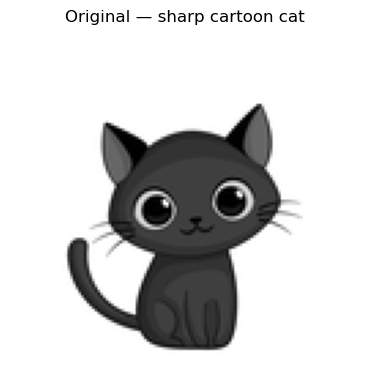

In [3]:
image_path = "test.jpg"
img_size = 128

img = Image.open(image_path).convert('L').resize((img_size, img_size), Image.LANCZOS)
u_true = np.array(img) / 255.0   # normalized to [0, 1]

print(f"Image shape : {u_true.shape}  |  range: [{u_true.min():.2f}, {u_true.max():.2f}]")

plt.figure(figsize=(4, 4))
plt.imshow(u_true, cmap='gray', vmin=0, vmax=1)
plt.title('Original — sharp cartoon cat')
plt.axis('off')
plt.tight_layout()
plt.show()

## Defining Functions

We define two functions: the 2D Gaussian Kernel and the Sparse Blur Matrix H. The 2D Gaussian Kernel functions builds the blur kernel, which is a small grid of weights that describes how a pixel spreads to its neighbors when blurred. The Sparse Blur Matrix H turns that kernel into a matrix $H$ so the blurring operation can be written as $H\mathbf{u}$, which CVXPY can work with directly.

The kernel we use is a **Gaussian kernel** — this is the blur shape our model assumes was applied to the image. As long as the actual blur matches this assumption, the model can reverse it.

## Build Kernel and Blur Matrix

#### 2D Gaussian Kernel

In [5]:
def get_gaussian_kernel(size=5, sigma=1.0):
    Xa = np.linspace(-(size - 1) / 2., (size - 1) / 2., size)
    xx, yy = np.meshgrid(Xa, Xa)
    kernel = np.exp(-0.5 * (np.square(xx) + np.square(yy)) / np.square(sigma))
    return kernel / np.sum(kernel)

#### Sparse Blur Matrix $H$

We need to represent the blurring operation as a matrix $H$ so we can write it as $H\mathbf{u}$ and plug it into CVXPY.

We will use **wrap boundary** for our problem. When the kernel goes past the edge of the image, it wraps around to the other side. This ensures every row of $H$ sums to exactly 1, meaning every pixel gets the full blur weight with nothing missing at the edges.

In [7]:
def create_sparse_blur_matrix(image_shape, kernel):
    M, N = image_shape
    kH, kW = kernel.shape
    pad_h, pad_w = kH // 2, kW // 2

    rows, cols, vals = [], [], []

    for i in range(M):
        for j in range(N):
            row_idx = i * N + j
            for ki in range(kH):
                for kj in range(kW):
                    # The code below defines the wrap boundary.
                    ii = (i + ki - pad_h) % M
                    jj = (j + kj - pad_w) % N
                    col_idx = ii * N + jj
                    rows.append(row_idx)
                    cols.append(col_idx)
                    vals.append(kernel[ki, kj])

    return sp.csr_matrix((vals, (rows, cols)), shape=(M * N, M * N))

## Apply Gaussian Blur and Build H

Kernel : 5×5,  sigma=1.5,  sum=1.0000
H shape: (16384, 16384),  nnz: 409600


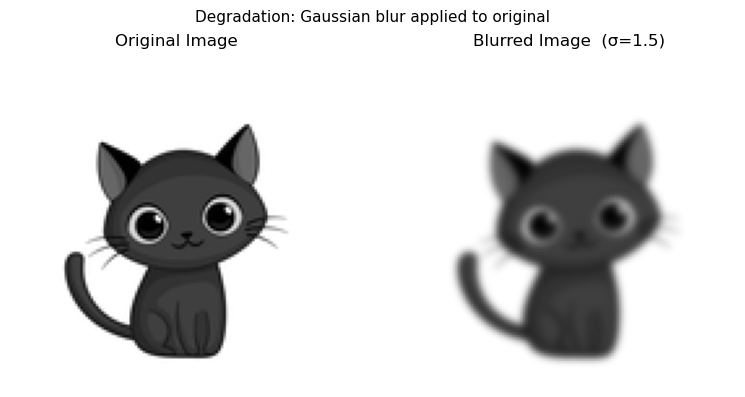

In [8]:
kernel_size = 5
sigma_value = 1.5

kernel = get_gaussian_kernel(size=kernel_size, sigma=sigma_value)
K_sparse = create_sparse_blur_matrix(u_true.shape, kernel)

# Applying the Gaussian blur
f_img = gaussian_filter(u_true, sigma=sigma_value)  
f_vec = f_img.flatten(order='C')                     

print(f"Kernel : {kernel_size}×{kernel_size},  sigma={sigma_value},  sum={kernel.sum():.4f}")
print(f"H shape: {K_sparse.shape},  nnz: {K_sparse.nnz}")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(u_true, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(f_img, cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'Blurred Image  (σ={sigma_value})')
axes[1].axis('off')
plt.suptitle('Degradation: Gaussian blur applied to original', fontsize=11)
plt.tight_layout()
plt.show()

## Deblurring the Image by Solving it with CVXPY

$$
\min_{\mathbf{u}}\; \underbrace{\|H\mathbf{u} - \mathbf{f}\|_2^2}_{\text{stay close to blurred input}} + \lambda\underbrace{\sum_{i,j}\|\nabla u_{i,j}\|_2}_{\text{keep edges sharp, regions flat}}
\quad\text{s.t.}\quad 0 \leq \mathbf{u} \leq 1
$$

**Why is this problem convex?**
$H$ is a fixed constant matrix, so $\|H\mathbf{u} - \mathbf{f}\|^2$ is a quadratic in $\mathbf{u}$ (convex). TV is also convex. Their sum is convex — CVXPY can solve it directly.

**What does λ control?**
- **λ too small**: If λ is too small, our de-blurred image would be still too blurry.
- **λ too large**: If λ is too large , our de-blurred image would be too smoothed and block. It will loses edge details.
- **λ just right**: This will result in the image's sharp edges restored and flat regions smooth.

λ=0.01  |  status: optimal  |  fidelity: 0.1246  |  TV: 375.9675
λ=0.025  |  status: optimal  |  fidelity: 0.3451  |  TV: 362.8192
λ=0.03  |  status: optimal  |  fidelity: 0.4321  |  TV: 359.6524
λ=0.05  |  status: optimal  |  fidelity: 0.8372  |  TV: 349.4050


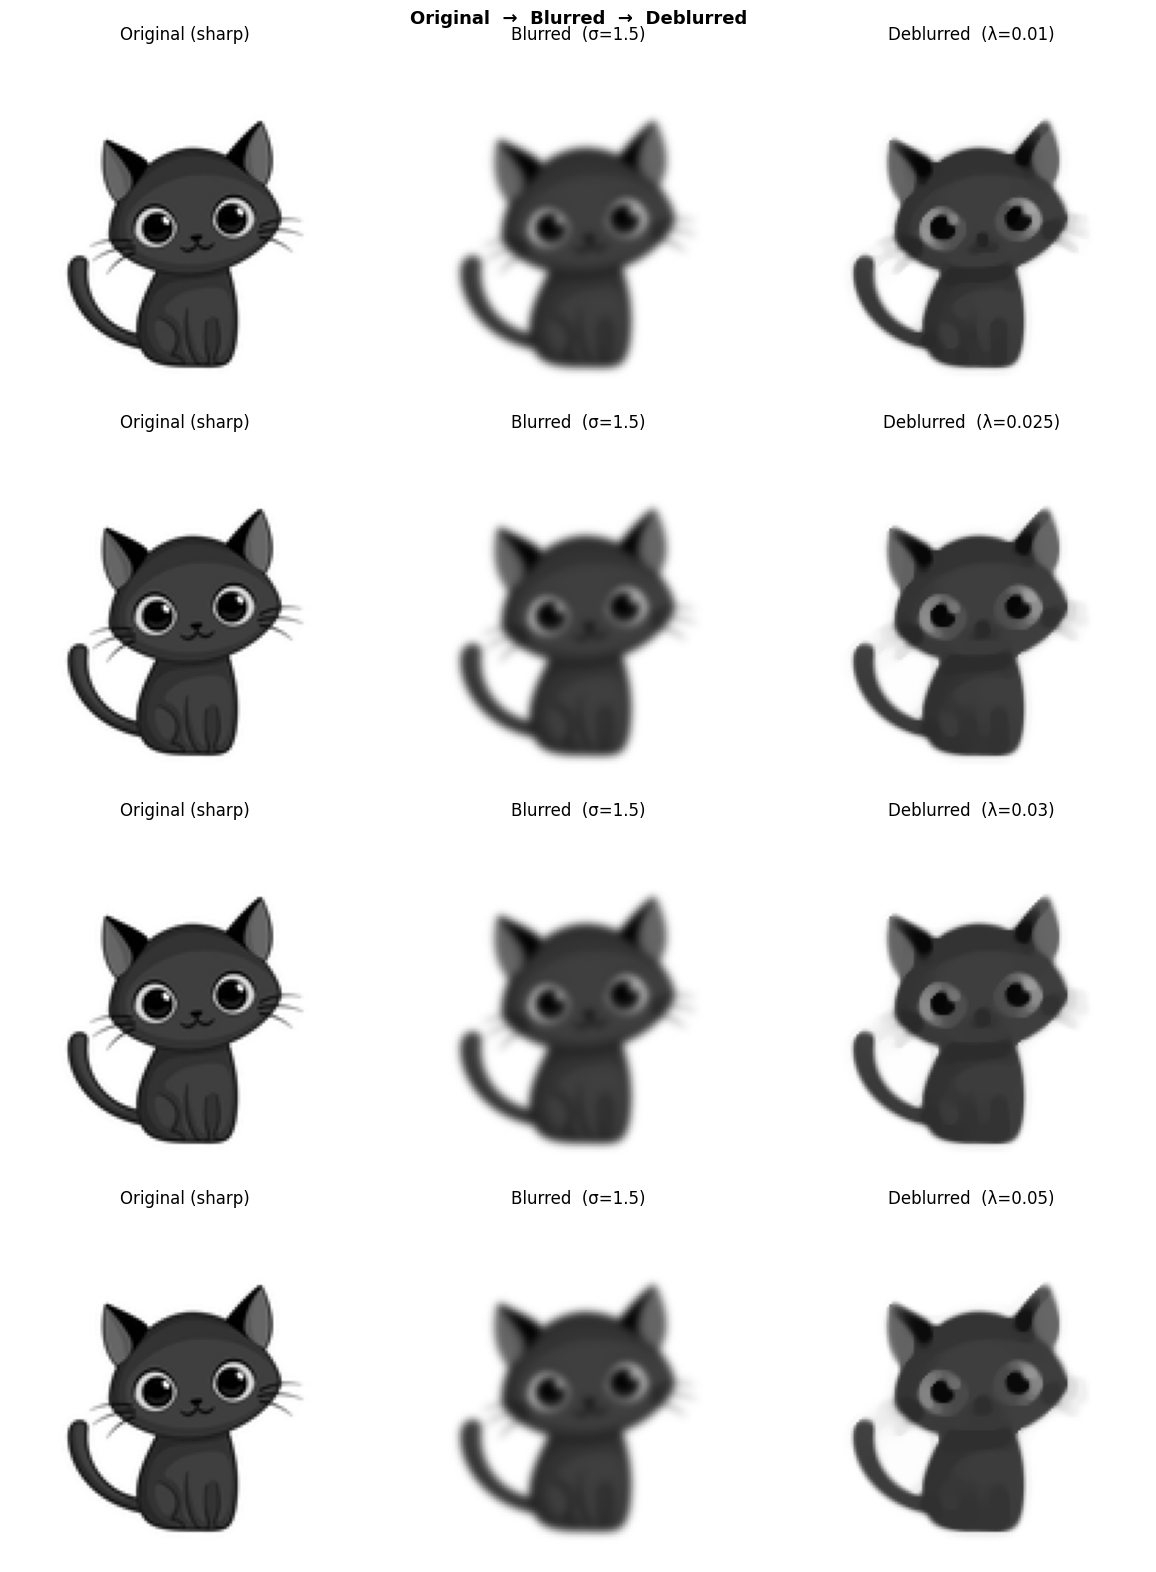

In [6]:
lambdas = [0.01, 0.025, 0.03, 0.05]

fig, axes = plt.subplots(len(lambdas), 3, figsize=(12, 4 * len(lambdas)))

for idx, LAMBDA_TV in enumerate(lambdas):
    U = cp.Variable((img_size, img_size))
    U_vec = cp.reshape(U, (img_size * img_size,), order='C')

    data_fidelity  = cp.sum_squares(K_sparse @ U_vec - f_vec)
    regularization = cp.tv(U)
    prob = cp.Problem(
        cp.Minimize(data_fidelity + LAMBDA_TV * regularization),
        [U >= 0, U <= 1]
    )
    prob.solve(solver=cp.SCS, verbose=False)

    u_recovered = np.clip(U.value, 0, 1)

    print(f"λ={LAMBDA_TV}  |  status: {prob.status}  |  "
          f"fidelity: {float(data_fidelity.value):.4f}  |  "
          f"TV: {float(regularization.value):.4f}")

    axes[idx, 0].imshow(u_true, cmap='gray', vmin=0, vmax=1)
    axes[idx, 0].set_title('Original Image')
    axes[idx, 0].axis('off')

    axes[idx, 1].imshow(f_img, cmap='gray', vmin=0, vmax=1)
    axes[idx, 1].set_title(f'Blurred Image (σ={sigma_value})')
    axes[idx, 1].axis('off')

    axes[idx, 2].imshow(u_recovered, cmap='gray', vmin=0, vmax=1)
    axes[idx, 2].set_title(f'Deblurred Image (λ={LAMBDA_TV})')
    axes[idx, 2].axis('off')

plt.suptitle('Original  →  Blurred  →  Deblurred', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('deblurred_results.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

**What we did:**
1. First, we loaded a sharp cartoon cat image which has flat regions and clean edges.
2. Next, the Gaussian blur (σ=1.5) kernel is applied to the image to simulate degradation — same σ used to build H so the model is consistent.
3. Solved one convex problem with CVXPY to recover the sharp image.

### λ tradeoff Conclusion:

| λ | Effect |
|---|---|
| 0.01 | The result of this one is too blurry and similar to our input. |
| 0.025 | This value yields moderate recovery |
| 0.03 | There is a good balance of sharpness and smoothness for this image |
| 0.05 | This output is too smooth and may soften fine edges. |

λ = 0.03 yields the best results of the image.